<a href="https://colab.research.google.com/github/Anant-0705/Anant-0705/blob/main/DL_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_model(layer):
    model = Sequential([
        Embedding(5000, 32),
        layer,
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model


In [ ]:
models = {
    "RNN": build_model(SimpleRNN(32)),
    "LSTM": build_model(LSTM(32)),
    "GRU": build_model(GRU(32))
}

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}")
    model.fit(x_train, y_train, epochs=1, batch_size=64)
    loss, acc = model.evaluate(x_test, y_test)
    print(f"{name} Accuracy:", acc)


Training RNN
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7482 - loss: 0.5021
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8226 - loss: 0.4058
RNN Accuracy: 0.8226400017738342

Training LSTM
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7689 - loss: 0.4582
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8475 - loss: 0.3411
LSTM Accuracy: 0.8475199937820435

Training GRU
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.7691 - loss: 0.4599
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8452 - loss: 0.3537
GRU Accuracy: 0.8452000021934509


LAB 5 — LSTM for Text Classification + Seq2Seq

In [ ]:
#LAB 5 — LSTM for Text Classification + Seq2Seq
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)
x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

In [ ]:
model = Sequential([
    Embedding(5000, 64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [ ]:
model.fit(x_train, y_train, epochs=2)

loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.7956 - loss: 0.4329
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8753 - loss: 0.2974
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8466 - loss: 0.3491
Accuracy: 0.8466399908065796


In [ ]:
#PART 2 — Seq2Seq
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense



In [ ]:
encoder_inputs = Input(shape=(None, 10))
encoder = LSTM(64, return_state=True)

In [ ]:
encoder_outputs, state_h, state_c = encoder(encoder_inputs)

encoder_states = [state_h, state_c]


In [ ]:
decoder_inputs = Input(shape=(None, 10))

decoder_lstm = LSTM(64, return_sequences=True, return_state=True)

In [ ]:
decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)


In [ ]:
decoder_dense = Dense(10, activation='softmax')

decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy')

print(model.summary())

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, None, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, None, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 64),      │     19,200 │ input_layer_4[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │     19,200 │ input_layer_5[0]… │
│                     │ 64), (None, 64),  │            │ lstm_2[0][1],     │
│                     │ (None, 64)]       │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None, 10)  │        650 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, None, 10)  │        110 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,160 (152.97 KB)

 Trainable params: 39,160 (152.97 KB)

 Non-trainable params: 0 (0.00 B)

None


LAB 6 — Attention Heatmaps in Seq2Seq

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Attention


In [ ]:
query = tf.random.normal((1, 5, 64))
value = tf.random.normal((1, 5, 64))

In [ ]:
attention = Attention()

output = attention([query, value])

print(output.shape)

(1, 5, 64)


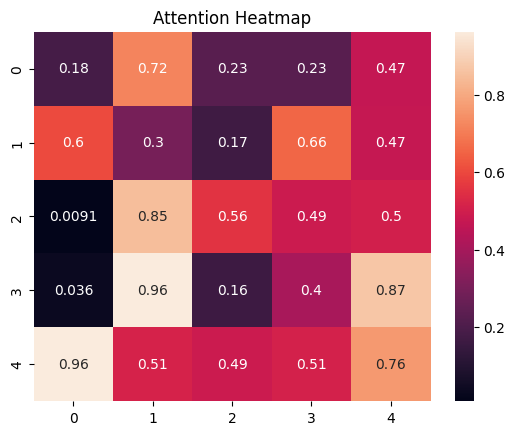

In [ ]:
#Heatmap Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

weights = np.random.rand(5,5)

sns.heatmap(weights, annot=True)

plt.title("Attention Heatmap")
plt.show()

LAB 7 — Fine-Tuning BERT

In [ ]:
#Sentiment Analysis using BERT
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

result = classifier("I love deep learning")

print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998319149017334}]


In [ ]:
from transformers import pipeline

qa = pipeline("question-answering")

result = qa(
    question="What is AI?",
    context="AI stands for Artificial Intelligence."
)

print(result)

LAB 8 — VAE + GAN + GCN

In [ ]:
#PART 1 — VAE
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [ ]:
input_dim = 784
latent_dim = 2

In [ ]:
inputs = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(inputs)
latent = Dense(latent_dim)(encoded)

In [ ]:
decoded = Dense(128, activation='relu')(latent)
outputs = Dense(input_dim, activation='sigmoid')(decoded)

In [ ]:
vae = Model(inputs, outputs)

In [ ]:
vae.compile(optimizer='adam', loss='mse')

print(vae.summary())

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,258 (790.07 KB)

 Trainable params: 202,258 (790.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#PART 2 — GAN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
generator = Sequential([
    Dense(128, activation='relu', input_dim=100),
    Dense(784, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
discriminator = Sequential([
    Dense(128, activation='relu', input_dim=784),
    Dense(1, activation='sigmoid')
])

In [ ]:
print(generator.summary())
print(discriminator.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#PART 3 — GCN

In [ ]:
!pip install torch-geometric
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.2 MB/s eta 0:00:00


In [ ]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]


Processing...
Done!


In [ ]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [ ]:
model = GCN()

In [ ]:
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)
